# Day 4 — Fund Performance Analytics

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Create charts directory
import os
os.makedirs('../reports/charts', exist_ok=True)

# Database connection
conn = sqlite3.connect('../bluestock_mf.db')


## 1. Compute Daily Returns

In [2]:

nav_df = pd.read_sql('SELECT n.amfi_code, f.scheme_name, d.date, n.nav FROM fact_nav n JOIN dim_date d ON n.date = d.date JOIN dim_fund f ON n.amfi_code = f.amfi_code', conn)
nav_df['date'] = pd.to_datetime(nav_df['date'])

nav_pivot = nav_df.pivot(index='date', columns='scheme_name', values='nav')
nav_pivot = nav_pivot.dropna(axis=1, how='all')

# Forward fill missing values before computing returns
nav_pivot = nav_pivot.ffill()

daily_returns = nav_pivot.pct_change().dropna()
print(f"Computed daily returns for {len(daily_returns.columns)} funds.")


Computed daily returns for 40 funds.


## 2. Compute CAGR (1yr, 3yr, 5yr)

In [3]:

def calculate_cagr(start_val, end_val, years):
    return (end_val / start_val) ** (1/years) - 1

# Assuming data goes up to the end date
end_date = nav_pivot.index[-1]
dates_1yr = end_date - pd.DateOffset(years=1)
dates_3yr = end_date - pd.DateOffset(years=3)
dates_5yr = end_date - pd.DateOffset(years=5)

# Find closest available dates
closest_1yr = nav_pivot.index[nav_pivot.index.get_indexer([dates_1yr], method='nearest')[0]]
closest_3yr = nav_pivot.index[nav_pivot.index.get_indexer([dates_3yr], method='nearest')[0]]
closest_5yr = nav_pivot.index[nav_pivot.index.get_indexer([dates_5yr], method='nearest')[0]]

cagr_data = {}
for col in nav_pivot.columns:
    try:
        val_end = nav_pivot.loc[end_date, col]
        val_1yr = nav_pivot.loc[closest_1yr, col]
        val_3yr = nav_pivot.loc[closest_3yr, col]
        val_5yr = nav_pivot.loc[closest_5yr, col]
        
        cagr_1yr = calculate_cagr(val_1yr, val_end, 1) if not pd.isna(val_1yr) else np.nan
        cagr_3yr = calculate_cagr(val_3yr, val_end, 3) if not pd.isna(val_3yr) else np.nan
        cagr_5yr = calculate_cagr(val_5yr, val_end, 5) if not pd.isna(val_5yr) else np.nan
        
        cagr_data[col] = {'1yr_CAGR': cagr_1yr, '3yr_CAGR': cagr_3yr, '5yr_CAGR': cagr_5yr}
    except KeyError:
        pass

cagr_df = pd.DataFrame(cagr_data).T
print(cagr_df.head())


                                               1yr_CAGR  3yr_CAGR  5yr_CAGR
ABSL Frontline Equity Fund - Regular - Growth  0.479241  0.289677  0.204427
ABSL Liquid Fund - Regular - Growth            0.072366  0.063158  0.057057
ABSL Small Cap Fund - Regular - Growth        -0.239860 -0.041524  0.069533
Axis Bluechip Fund - Direct - Growth           0.197667  0.208168  0.069174
Axis Bluechip Fund - Regular - Growth          0.016091  0.005259  0.055826


## 3. & 4. Sharpe and Sortino Ratios

In [4]:

rf_rate = 0.065
rf_daily = (1 + rf_rate) ** (1/252) - 1

ratios = {}
for col in daily_returns.columns:
    ret = daily_returns[col]
    excess_ret = ret - rf_daily
    
    # Annualized metrics
    ann_ret = excess_ret.mean() * 252
    ann_vol = ret.std() * np.sqrt(252)
    
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan
    
    downside_ret = ret[ret < 0]
    downside_vol = downside_ret.std() * np.sqrt(252)
    sortino = ann_ret / downside_vol if downside_vol != 0 else np.nan
    
    ratios[col] = {'Sharpe_Ratio': sharpe, 'Sortino_Ratio': sortino}

ratios_df = pd.DataFrame(ratios).T
print(ratios_df.head())


                                               Sharpe_Ratio  Sortino_Ratio
ABSL Frontline Equity Fund - Regular - Growth      0.733767       1.088168
ABSL Liquid Fund - Regular - Growth               -4.213617      -7.920605
ABSL Small Cap Fund - Regular - Growth             0.061866       0.088968
Axis Bluechip Fund - Direct - Growth              -0.030013      -0.043292
Axis Bluechip Fund - Regular - Growth             -0.113908      -0.164493


## 5. Alpha and Beta (vs Nifty 100)

In [5]:

# Load benchmark indices
bench_df = pd.read_csv('../data/processed/10_benchmark_indices_clean.csv')
nifty100 = bench_df[bench_df['index_name'] == 'Nifty 100'].copy()
nifty100['date'] = pd.to_datetime(nifty100['date'])
nifty100 = nifty100.set_index('date').sort_index()

# Forward fill missing dates
nifty100 = nifty100.reindex(nav_pivot.index).ffill()
nifty100_returns = nifty100['close_value'].pct_change().dropna()

# Align indices
aligned_returns = pd.concat([daily_returns, nifty100_returns.rename('Nifty100')], axis=1).dropna()

alpha_beta = {}
for col in daily_returns.columns:
    if col in aligned_returns.columns:
        slope, intercept, r_value, p_value, std_err = stats.linregress(aligned_returns['Nifty100'], aligned_returns[col])
        ann_alpha = intercept * 252
        alpha_beta[col] = {'Alpha': ann_alpha, 'Beta': slope}

alpha_beta_df = pd.DataFrame(alpha_beta).T

# Save to CSV
alpha_beta_df.to_csv('../data/processed/alpha_beta.csv')
print("Alpha and Beta computed and saved to alpha_beta.csv")
print(alpha_beta_df.head())


Alpha and Beta computed and saved to alpha_beta.csv
                                               Alpha  Beta
ABSL Frontline Equity Fund - Regular - Growth    NaN   NaN
ABSL Liquid Fund - Regular - Growth              NaN   NaN
ABSL Small Cap Fund - Regular - Growth           NaN   NaN
Axis Bluechip Fund - Direct - Growth             NaN   NaN
Axis Bluechip Fund - Regular - Growth            NaN   NaN


/var/folders/72/dks5r8fs7b76wcvnkstzx74h0000gn/T/ipykernel_53515/435767911.py:17: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r_value, p_value, std_err = stats.linregress(aligned_returns['Nifty100'], aligned_returns[col])


## 6. Maximum Drawdown

In [6]:

drawdowns = {}
for col in nav_pivot.columns:
    cum_max = nav_pivot[col].cummax()
    drawdown = (nav_pivot[col] / cum_max) - 1
    max_dd = drawdown.min()
    drawdowns[col] = {'Max_Drawdown': max_dd}

max_dd_df = pd.DataFrame(drawdowns).T
print(max_dd_df.head())


                                               Max_Drawdown
ABSL Frontline Equity Fund - Regular - Growth     -0.112916
ABSL Liquid Fund - Regular - Growth               -0.001622
ABSL Small Cap Fund - Regular - Growth            -0.354469
Axis Bluechip Fund - Direct - Growth              -0.217514
Axis Bluechip Fund - Regular - Growth             -0.144016


## 7. Fund Scorecard

In [7]:

# Combine all metrics
metrics_df = pd.concat([cagr_df, ratios_df, alpha_beta_df, max_dd_df], axis=1)

# Fetch expense ratio
fund_info = pd.read_sql('SELECT scheme_name, expense_ratio_pct FROM dim_fund', conn).set_index('scheme_name')
metrics_df = metrics_df.join(fund_info)

# Ranking
metrics_df['rank_3yr'] = metrics_df['3yr_CAGR'].rank(pct=True)
metrics_df['rank_sharpe'] = metrics_df['Sharpe_Ratio'].rank(pct=True)
metrics_df['rank_alpha'] = metrics_df['Alpha'].rank(pct=True)
metrics_df['rank_expense'] = metrics_df['expense_ratio_pct'].rank(pct=True, ascending=False) # Lower is better
metrics_df['rank_max_dd'] = metrics_df['Max_Drawdown'].rank(pct=True) # Less negative is better

# Composite score (0-100)
metrics_df['Score'] = (
    0.30 * metrics_df['rank_3yr'] +
    0.25 * metrics_df['rank_sharpe'] +
    0.20 * metrics_df['rank_alpha'] +
    0.15 * metrics_df['rank_expense'] +
    0.10 * metrics_df['rank_max_dd']
) * 100

scorecard = metrics_df.sort_values(by='Score', ascending=False)

# Save to CSV
scorecard.to_csv('../data/processed/fund_scorecard.csv')
print("Fund scorecard computed and saved to fund_scorecard.csv")
print(scorecard[['Score', '3yr_CAGR', 'Sharpe_Ratio', 'Alpha', 'expense_ratio_pct', 'Max_Drawdown']].head())


Fund scorecard computed and saved to fund_scorecard.csv
                                               Score  3yr_CAGR  Sharpe_Ratio  \
ABSL Frontline Equity Fund - Regular - Growth    NaN  0.289677      0.733767   
ABSL Liquid Fund - Regular - Growth              NaN  0.063158     -4.213617   
ABSL Small Cap Fund - Regular - Growth           NaN -0.041524      0.061866   
Axis Bluechip Fund - Direct - Growth             NaN  0.208168     -0.030013   
Axis Bluechip Fund - Regular - Growth            NaN  0.005259     -0.113908   

                                               Alpha  expense_ratio_pct  \
ABSL Frontline Equity Fund - Regular - Growth    NaN               1.60   
ABSL Liquid Fund - Regular - Growth              NaN               0.79   
ABSL Small Cap Fund - Regular - Growth           NaN               1.53   
Axis Bluechip Fund - Direct - Growth             NaN               0.75   
Axis Bluechip Fund - Regular - Growth            NaN               1.64   

            

## 8. Benchmark Comparison Chart

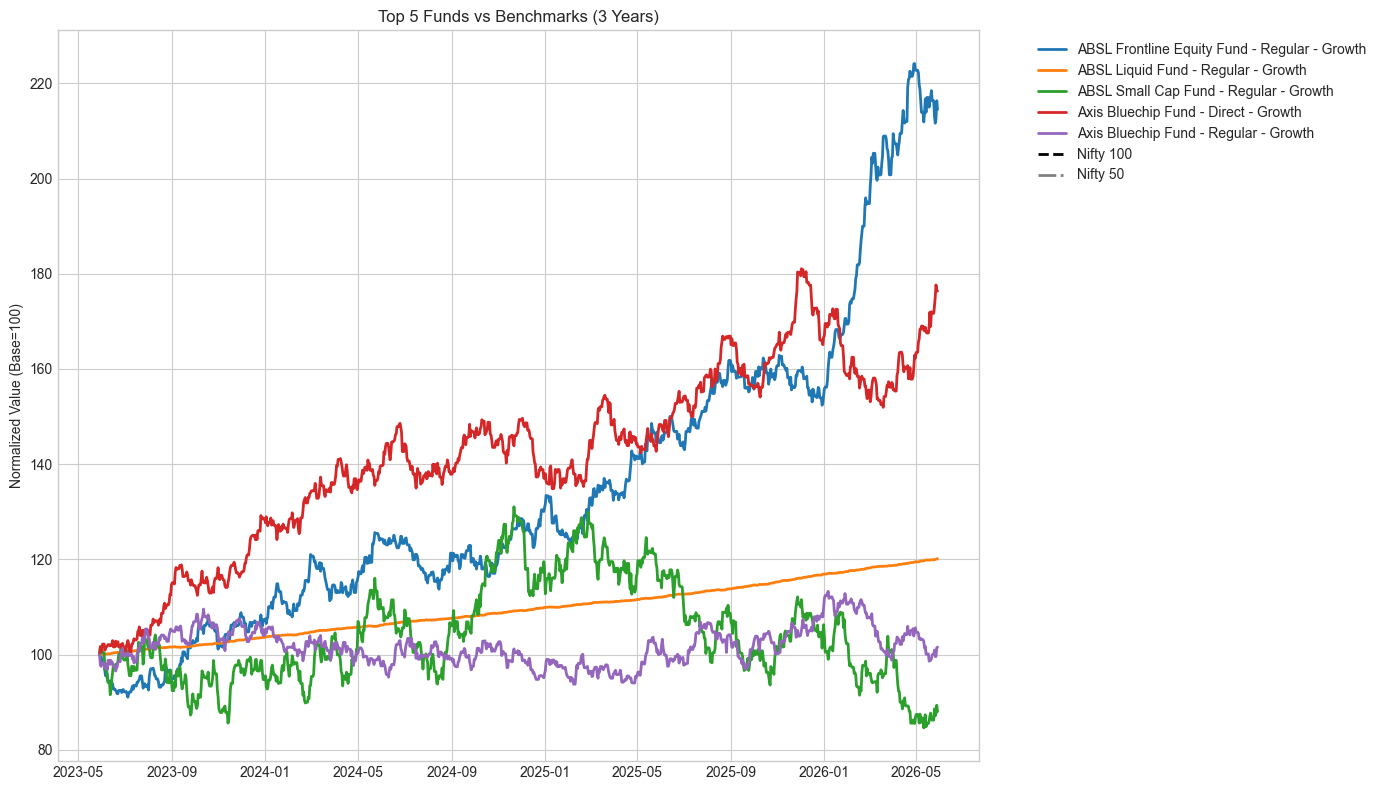

In [8]:

# Top 5 funds by Score
top_5_funds = scorecard.index[:5]

nifty50 = bench_df[bench_df['index_name'] == 'Nifty 50'].copy()
nifty50['date'] = pd.to_datetime(nifty50['date'])
nifty50 = nifty50.set_index('date').sort_index()

# Plot over last 3 years
start_plot = closest_3yr

plot_data = nav_pivot.loc[start_plot:, top_5_funds].copy()
plot_data['Nifty 100'] = nifty100.loc[start_plot:, 'close_value']
plot_data['Nifty 50'] = nifty50.loc[start_plot:, 'close_value']

# Normalize
plot_data = (plot_data / plot_data.bfill().iloc[0]) * 100

plt.figure(figsize=(14, 8))
for col in top_5_funds:
    plt.plot(plot_data.index, plot_data[col], label=col, linewidth=2)

plt.plot(plot_data.index, plot_data['Nifty 100'], label='Nifty 100', color='black', linestyle='--', linewidth=2)
plt.plot(plot_data.index, plot_data['Nifty 50'], label='Nifty 50', color='gray', linestyle='-.', linewidth=2)

plt.title('Top 5 Funds vs Benchmarks (3 Years)')
plt.ylabel('Normalized Value (Base=100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../reports/charts/10_benchmark_comparison.png")
plt.show()
